In [1]:
from keras.models import Sequential
from keras import layers
from keras.optimizers import Adam
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import random

2025-11-02 14:02:15.371226: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-02 14:02:15.388735: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-02 14:02:16.008978: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-02 14:02:17.945565: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [14]:

(x_train_1, y_train_1), (x_test_1, y_test_1) = tf.keras.datasets.fashion_mnist.load_data()
(x_train_2, y_train_2), (x_test_2, y_test_2) = tf.keras.datasets.mnist.load_data()
(x_train_3, y_train_3), (x_test_3, y_test_3) = tf.keras.datasets.cifar10.load_data()

num_classes = 10
y_train_1 = tf.keras.utils.to_categorical(y_train_1, num_classes)
y_test_1  = tf.keras.utils.to_categorical(y_test_1, num_classes)
y_train_2 = tf.keras.utils.to_categorical(y_train_2, num_classes)
y_test_2  = tf.keras.utils.to_categorical(y_test_2, num_classes)
y_train_3 = y_train_3.reshape(-1) if y_train_3.ndim > 1 else y_train_3
y_test_3  = y_test_3.reshape(-1)  if y_test_3.ndim > 1 else y_test_3
y_train_3 = tf.keras.utils.to_categorical(y_train_3, num_classes)
y_test_3  = tf.keras.utils.to_categorical(y_test_3, num_classes)

In [15]:
print('fashion mnist | train: ', x_train_1.shape, y_train_1.shape, ' | test: ', x_test_1.shape, y_test_1.shape)
print('digit mnist | train: ', x_train_2.shape, y_train_2.shape, ' | test: ', x_test_2.shape, y_test_2.shape)
print('cipher 10 | train: ', x_train_3.shape, y_train_3.shape, ' | test: ', x_test_3.shape, y_test_3.shape)

fashion mnist | train:  (60000, 28, 28) (60000, 10)  | test:  (10000, 28, 28) (10000, 10)
digit mnist | train:  (60000, 28, 28) (60000, 10)  | test:  (10000, 28, 28) (10000, 10)
cipher 10 | train:  (50000, 32, 32, 3) (50000, 10)  | test:  (10000, 32, 32, 3) (10000, 10)


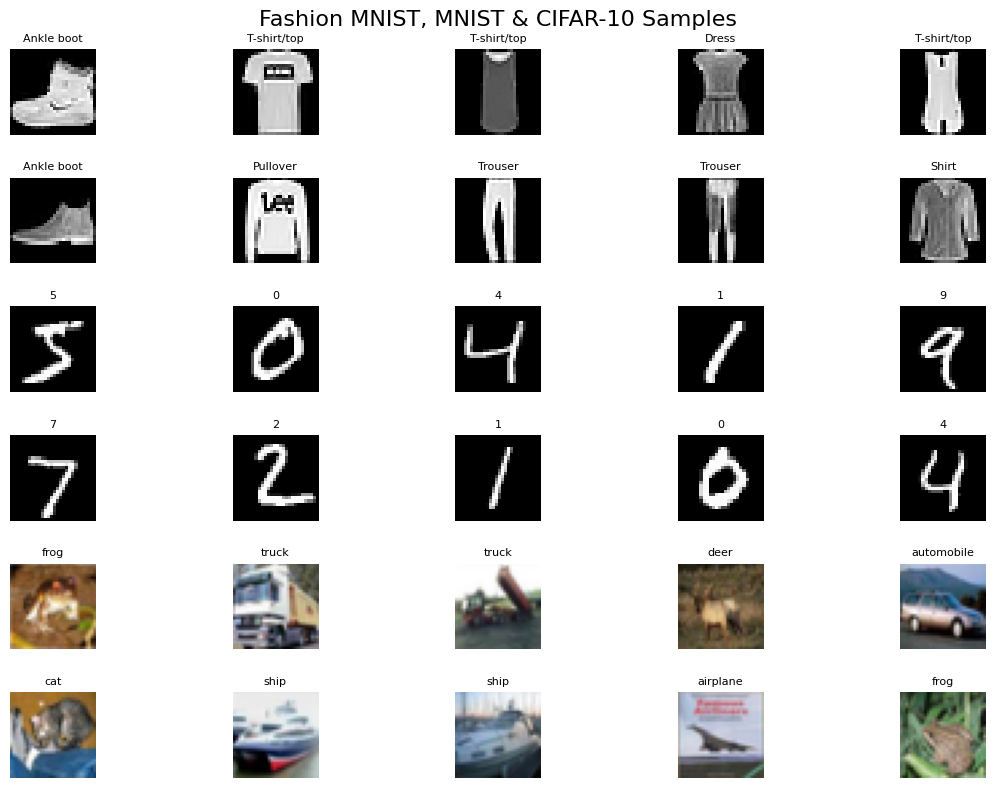

In [16]:
fashion_labels = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
                  'Sandal','Shirt','Sneaker','Bag','Ankle boot']
mnist_labels = [str(i) for i in range(10)]
cifar_labels = ['airplane','automobile','bird','cat','deer',
                'dog','frog','horse','ship','truck']

fig, axes = plt.subplots(6, 5, figsize=(12, 8))
fig.suptitle("Fashion MNIST, MNIST & CIFAR-10 Samples", fontsize=16)

datasets = [
    ("Fashion MNIST - Train", x_train_1, y_train_1, fashion_labels, 'gray'),
    ("Fashion MNIST - Test", x_test_1, y_test_1, fashion_labels, 'gray'),
    ("MNIST - Train", x_train_2, y_train_2, mnist_labels, 'gray'),
    ("MNIST - Test", x_test_2, y_test_2, mnist_labels, 'gray'),
    ("CIFAR-10 - Train", x_train_3, y_train_3, cifar_labels, None),
    ("CIFAR-10 - Test", x_test_3, y_test_3, cifar_labels, None),
]

for row, (title, x_data, y_data, labels, cmap) in enumerate(datasets):
    for col in range(5):
        ax = axes[row, col]
        ax.axis("off")
        img = x_data[col]
        if cmap:
            ax.imshow(img, cmap=cmap)
        else:
            ax.imshow(img)
        # Decode label: if labels were converted to one-hot (shape (N, num_classes)) use argmax
        if y_data.ndim > 1 and getattr(y_data, 'shape', None) and y_data.shape[1] > 1:
            label_idx = np.argmax(y_data[col])
        else:
            # y_data may be shape (N,1) or (N,) -> handle both
            label_idx = y_data[col][0] if y_data.ndim > 1 else y_data[col]
        ax.set_title(labels[int(label_idx)], fontsize=8)
    axes[row, 0].set_ylabel(title, fontsize=10, rotation=0, labelpad=50, va='center')

plt.tight_layout()
plt.subplots_adjust(top=0.93, hspace=0.5)
plt.show()


In [17]:
# Normalize all input data to [0, 1] float32 (no flatten, use Flatten layer in model)
x_train_1 = x_train_1.astype('float32') / 255.0
x_test_1  = x_test_1.astype('float32')  / 255.0
x_train_2 = x_train_2.astype('float32') / 255.0
x_test_2  = x_test_2.astype('float32')  / 255.0
x_train_3 = x_train_3.astype('float32') / 255.0
x_test_3  = x_test_3.astype('float32')  / 255.0

In [19]:
# Optimal FCNN model for Fashion MNIST using Keras Sequential
model1 = Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

model1.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model1.summary()

/home/zahin/Desktop/AI_LAB/.venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,554 (955.29 KB)

 Trainable params: 243,658 (951.79 KB)

 Non-trainable params: 896 (3.50 KB)

In [20]:
# Train model1 on Fashion MNIST
history1 = model1.fit(
    x_train_1, y_train_1,
    validation_data=(x_test_1, y_test_1),
    epochs=10,
    batch_size=32,
    verbose=1
 )

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.7770 - loss: 0.6378 - val_accuracy: 0.8244 - val_loss: 0.4747
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.7770 - loss: 0.6378 - val_accuracy: 0.8244 - val_loss: 0.4747
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8243 - loss: 0.4980 - val_accuracy: 0.8414 - val_loss: 0.4319
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8243 - loss: 0.4980 - val_accuracy: 0.8414 - val_loss: 0.4319
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8317 - loss: 0.4721 - val_accuracy: 0.8395 - val_loss: 0.4392
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8317 - loss: 0.4721 - val_accuracy: 0.8395 - val_loss: 0.4392
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8380 - loss: 0.4530 - val_accuracy: 0.8449 - val_loss: 0.4173
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8380 - loss: 0

In [21]:
# Optimal FCNN model for MNIST using Keras Sequential
model2 = Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

model2.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,554 (955.29 KB)

 Trainable params: 243,658 (951.79 KB)

 Non-trainable params: 896 (3.50 KB)

In [22]:
# Train model2 on MNIST
history2 = model2.fit(
    x_train_2, y_train_2,
    validation_data=(x_test_2, y_test_2),
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.8796 - loss: 0.3956 - val_accuracy: 0.9585 - val_loss: 0.1321
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.8796 - loss: 0.3956 - val_accuracy: 0.9585 - val_loss: 0.1321
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9349 - loss: 0.2170 - val_accuracy: 0.9680 - val_loss: 0.1065
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9349 - loss: 0.2170 - val_accuracy: 0.9680 - val_loss: 0.1065
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9455 - loss: 0.1828 - val_accuracy: 0.9726 - val_loss: 0.0877
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9455 - loss: 0.1828 - val_accuracy: 0.9726 - val_loss: 0.0877
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9511 - loss: 0.1638 - val_accuracy: 0.9757 - val_loss: 0.0779
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9511 - loss: 0

In [23]:
# Optimal FCNN model for CIFAR-10 using Keras Sequential
model3 = Sequential([
    layers.Flatten(input_shape=(32, 32, 3)),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

model3.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,742,474 (6.65 MB)

 Trainable params: 1,740,682 (6.64 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [24]:
# Train model3 on CIFAR-10
history3 = model3.fit(
    x_train_3, y_train_3,
    validation_data=(x_test_3, y_test_3),
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.3062 - loss: 1.9592 - val_accuracy: 0.3790 - val_loss: 1.7195
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.3062 - loss: 1.9592 - val_accuracy: 0.3790 - val_loss: 1.7195
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.3598 - loss: 1.7802 - val_accuracy: 0.3958 - val_loss: 1.7000
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.3598 - loss: 1.7802 - val_accuracy: 0.3958 - val_loss: 1.7000
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.3721 - loss: 1.7515 - val_accuracy: 0.4101 - val_loss: 1.6739
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.3721 - loss: 1.7515 - val_accuracy: 0.4101 - val_loss: 1.6739
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.3756 - loss: 1.7375 - val_accuracy: 0.4157 - val_loss: 1.6205
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.3756 -

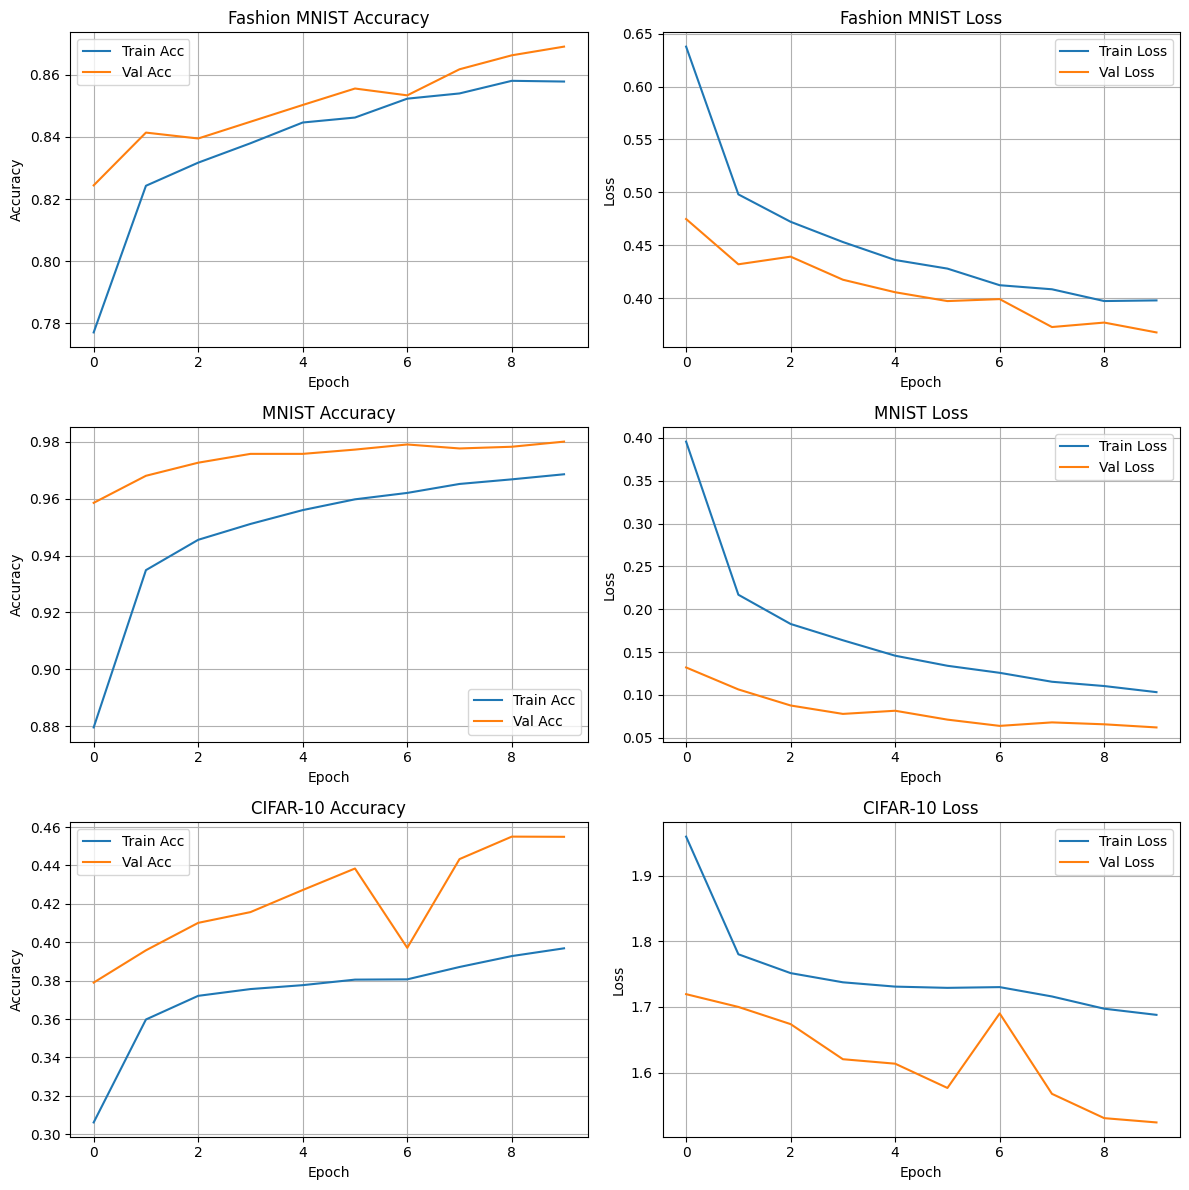

In [25]:
# Function to plot accuracy and loss for all 3 models

def plot_all_histories(histories, titles):
    """
    histories: list of Keras History objects (history1, history2, history3)
    titles: list of strings, e.g. ["Fashion MNIST", "MNIST", "CIFAR-10"]
    """
    fig, axes = plt.subplots(3, 2, figsize=(12, 12))
    for i, (history, title) in enumerate(zip(histories, titles)):
        # Accuracy
        axes[i, 0].plot(history.history['accuracy'], label='Train Acc')
        axes[i, 0].plot(history.history['val_accuracy'], label='Val Acc')
        axes[i, 0].set_title(f"{title} Accuracy")
        axes[i, 0].set_xlabel("Epoch")
        axes[i, 0].set_ylabel("Accuracy")
        axes[i, 0].legend()
        axes[i, 0].grid(True)
        # Loss
        axes[i, 1].plot(history.history['loss'], label='Train Loss')
        axes[i, 1].plot(history.history['val_loss'], label='Val Loss')
        axes[i, 1].set_title(f"{title} Loss")
        axes[i, 1].set_xlabel("Epoch")
        axes[i, 1].set_ylabel("Loss")
        axes[i, 1].legend()
        axes[i, 1].grid(True)
    plt.tight_layout()
    plt.show()

# Example usage (uncomment to plot after training all models):
plot_all_histories([history1, history2, history3], ["Fashion MNIST", "MNIST", "CIFAR-10"])

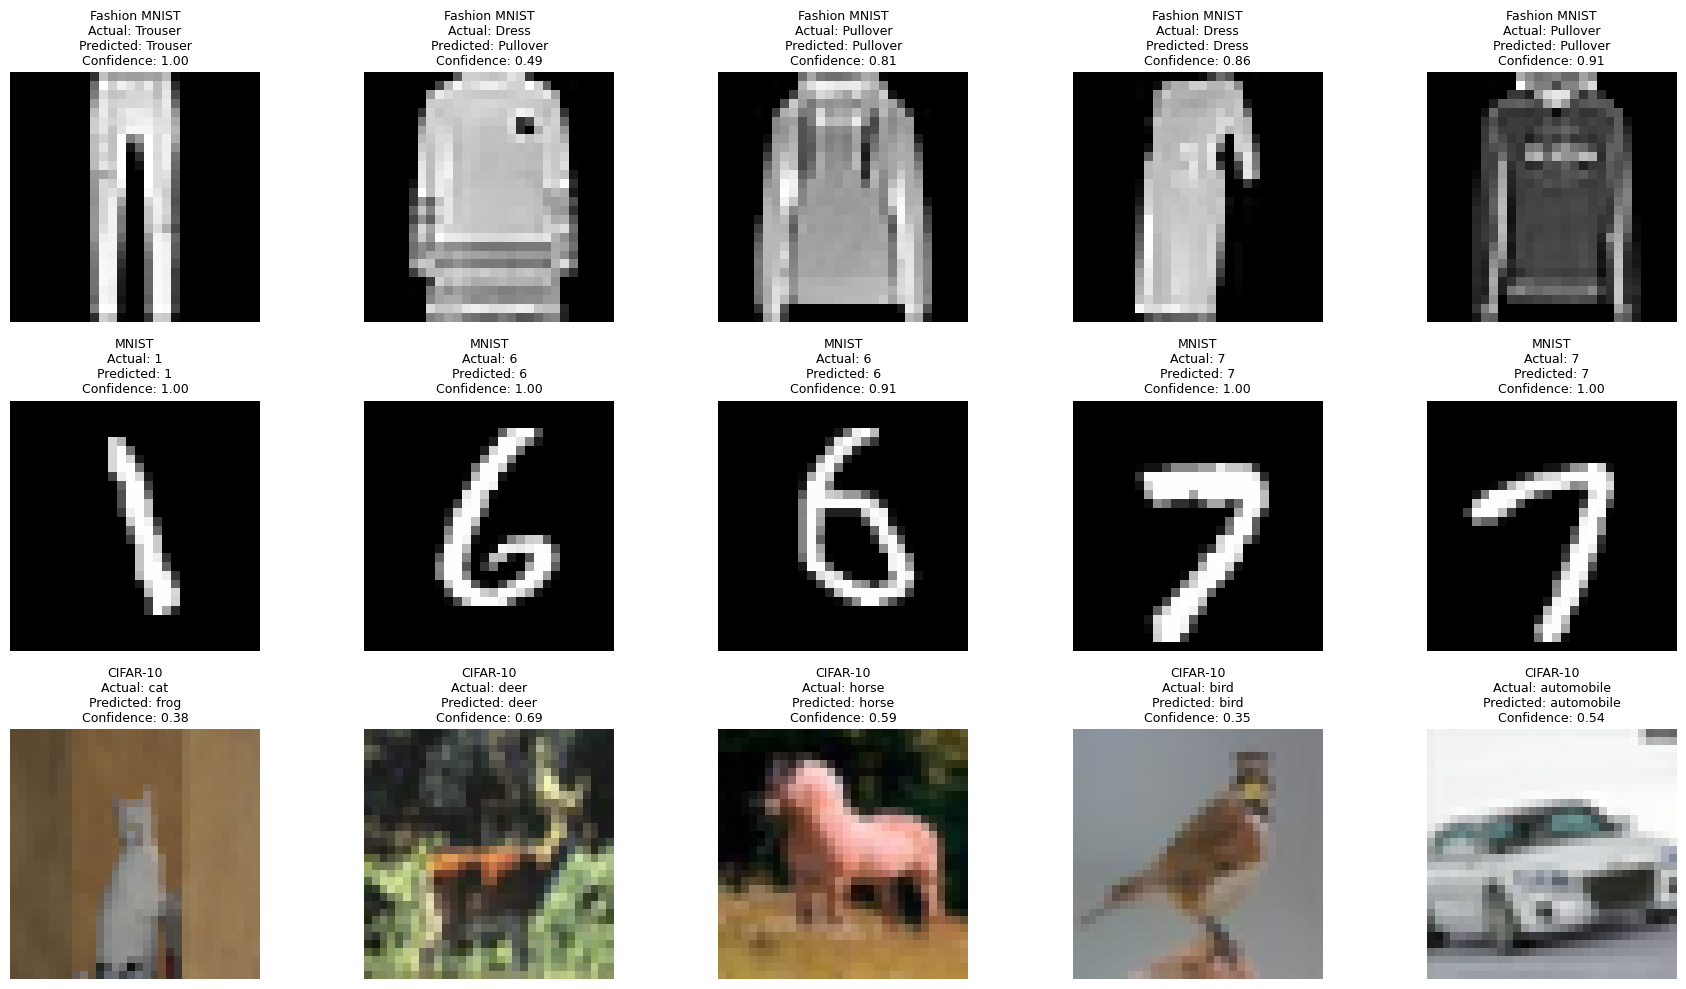

In [28]:
# Function to plot 5 random predictions for each model with confidence

def plot_random_predictions(models, x_tests, y_tests, label_lists, titles):
    """
    models: list of trained keras models
    x_tests: list of test datasets (x_test_1, x_test_2, x_test_3)
    y_tests: list of test labels (one-hot)
    label_lists: list of class label lists (e.g. fashion_labels, mnist_labels, cifar_labels)
    titles: list of dataset names
    """
    fig, axes = plt.subplots(3, 5, figsize=(18, 10))
    for row, (model, x_test, y_test, labels, title) in enumerate(zip(models, x_tests, y_tests, label_lists, titles)):
        idxs = random.sample(range(x_test.shape[0]), 5)
        preds = model.predict(x_test[idxs], verbose=0)
        for col, (i, pred) in enumerate(zip(idxs, preds)):
            ax = axes[row, col]
            # Get actual and predicted label
            actual_idx = np.argmax(y_test[i])
            pred_idx = np.argmax(pred)
            confidence = np.max(pred)
            # Plot image
            img = x_test[i]
            if img.ndim == 3 and img.shape[-1] == 1:
                img = img.squeeze(-1)
            if img.ndim == 2:
                ax.imshow(img, cmap='gray')
            else:
                ax.imshow(img)
            ax.axis('off')
            ax.set_title(f"{title}\nActual: {labels[actual_idx]}\nPredicted: {labels[pred_idx]}\nConfidence: {confidence:.2f}", fontsize=9)
    plt.tight_layout()
    plt.show()

# Example usage (uncomment to run after training):
plot_random_predictions(
    [model1, model2, model3],
    [x_test_1, x_test_2, x_test_3],
    [y_test_1, y_test_2, y_test_3],
    [fashion_labels, mnist_labels, cifar_labels],
    ["Fashion MNIST", "MNIST", "CIFAR-10"]
)